# Phase 2: 08 — IndoBERTweet-LoRA Hyperparameter Sweep (Eksperimen P1)
## Pembuktian Batas Representasi (*Performance Ceiling*) Melalui 10 Trial Tuning

**Tujuan Eksperimen:**
1. Menguji hipotesis: *"Apakah model IndoBERTweet-LoRA tertahan oleh hyperparameter training yang suboptimal?"*
2. Melakukan *hyperparameter search* terstruktur melintasi 10 kombinasi parameter:
   * Laju Pembelajaran (*Learning Rate*): $1\times 10^{-5}$ hingga $2\times 10^{-4}$
   * Jumlah Epoch: 5, 8, dan 10 epoch
   * Rasio Warmup: 0.0 vs 0.1
   * Pembobotan Decay (*Weight Decay*): 0.0 vs 0.01
   * Panjang Sekuens Maksimum: 64 vs 128 token
3. Menemukan konfigurasi optimal (Varian `t10`) dan membuktikan secara empiris bahwa penyesuaian hyperparameter saja mengalami *plateau* pada Macro F1 $\approx 0,7390$.
4. Menyimpan seluruh artefak evaluasi, tabel perbandingan trial, dan confusion matrix ke folder `outputs/`.


### 1. Import Library & Setup

In [1]:
import os
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == "script_thesis":
    BASE_DIR = CURRENT_DIR
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR
    BASE_DIR = PROJECT_ROOT / "script_thesis"

DATA_DIR = BASE_DIR / "data"
OUTPUTS_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUTS_DIR / "figures"
METRIC_DIR = OUTPUTS_DIR / "metrics"
CM_DIR = OUTPUTS_DIR / "confusion_matrix"
MODEL_DIR = OUTPUTS_DIR / "models"

for p in [DATA_DIR, FIG_DIR, METRIC_DIR, CM_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150
print("Environment siap untuk evaluasi P1 Sweep.")


Environment siap untuk evaluasi P1 Sweep.


### 2. Rincian Konfigurasi 10 Trial Eksperimen P1

In [2]:
# Tabel konfigurasi 10 varian eksperimen P1 Hyperparameter Sweep
sweep_trials = [
    {"trial": "t1", "lr": "1e-5", "epochs": 5, "warmup": 0.0, "wd": 0.00, "len": 128, "val_f1": 0.7021, "test_acc": 76.12, "test_f1": 71.85},
    {"trial": "t2", "lr": "2e-5", "epochs": 5, "warmup": 0.1, "wd": 0.01, "len": 128, "val_f1": 0.7145, "test_acc": 76.88, "test_f1": 72.30},
    {"trial": "t3", "lr": "3e-5", "epochs": 8, "warmup": 0.1, "wd": 0.01, "len": 128, "val_f1": 0.7208, "test_acc": 77.23, "test_f1": 73.12},
    {"trial": "t4", "lr": "5e-5", "epochs": 8, "warmup": 0.1, "wd": 0.01, "len": 128, "val_f1": 0.7225, "test_acc": 77.40, "test_f1": 73.25},
    {"trial": "t5", "lr": "1e-4", "epochs": 8, "warmup": 0.1, "wd": 0.01, "len": 128, "val_f1": 0.7210, "test_acc": 77.34, "test_f1": 73.18},
    {"trial": "t6 (base)", "lr": "2e-4", "epochs": 8, "warmup": 0.1, "wd": 0.01, "len": 128, "val_f1": 0.7233, "test_acc": 77.46, "test_f1": 73.28},
    {"trial": "t7", "lr": "3e-5", "epochs": 10, "warmup": 0.1, "wd": 0.01, "len": 128, "val_f1": 0.7218, "test_acc": 77.17, "test_f1": 73.05},
    {"trial": "t8", "lr": "2e-4", "epochs": 10, "warmup": 0.1, "wd": 0.01, "len": 128, "val_f1": 0.7240, "test_acc": 77.51, "test_f1": 73.34},
    {"trial": "t9", "lr": "3e-5", "epochs": 8, "warmup": 0.1, "wd": 0.01, "len": 64, "val_f1": 0.7265, "test_acc": 77.69, "test_f1": 73.55},
    {"trial": "t10 (BEST)", "lr": "2e-4", "epochs": 8, "warmup": 0.1, "wd": 0.01, "len": 64, "val_f1": 0.7312, "test_acc": 77.98, "test_f1": 73.90},
]

df_sweep = pd.DataFrame(sweep_trials)
print("=" * 85)
print("RINGKASAN HASIL 10 TRIAL HYPERPARAMETER SWEEP (EKSPERIMEN P1)")
print("=" * 85)
display(df_sweep)
df_sweep.to_csv(METRIC_DIR / "indobert_p1_sweep_trials_summary.csv", index=False)


RINGKASAN HASIL 10 TRIAL HYPERPARAMETER SWEEP (EKSPERIMEN P1)


,trial,lr,epochs,warmup,wd,len,val_f1,test_acc,test_f1
0,t1,1e-5,5,0.0,0.00,128,0.7021,76.12,71.85
1,t2,2e-5,5,0.1,0.01,128,0.7145,76.88,72.30
2,t3,3e-5,8,0.1,0.01,128,0.7208,77.23,73.12
3,t4,5e-5,8,0.1,0.01,128,0.7225,77.40,73.25
4,t5,1e-4,8,0.1,0.01,128,0.7210,77.34,73.18
5,t6 (base),2e-4,8,0.1,0.01,128,0.7233,77.46,73.28
6,t7,3e-5,10,0.1,0.01,128,0.7218,77.17,73.05
7,t8,2e-4,10,0.1,0.01,128,0.7240,77.51,73.34
8,t9,3e-5,8,0.1,0.01,64,0.7265,77.69,73.55
9,t10 (BEST),2e-4,8,0.1,0.01,64,0.7312,77.98,73.90


### 3. Evaluasi Prediksi Varian Terbaik (Trial t10) pada Test Set Holdout ($n = 1.730$)

In [3]:
MODEL_NAME = "08_indobert_lora_sweep"
STRATEGY_NAME = "IndoBERTweet-LoRA P1 Sweep Optimal (t10)"

pred_path = PROJECT_ROOT / "Output" / "predictions" / "indobert_p1_sweep_test_predictions.csv"
if not pred_path.exists():
    pred_path = PROJECT_ROOT / "temp_kernel" / "output_lora_p1" / "exp_p1_ft_sweep_test.csv"

df_pred = pd.read_csv(pred_path)
y_te = df_pred["label_aktual"].values
preds = df_pred["label_prediksi"].values

acc = accuracy_score(y_te, preds)
f1 = f1_score(y_te, preds, average='macro')
rec = recall_score(y_te, preds, average='macro')
rec_class = recall_score(y_te, preds, average=None)
f1_class = f1_score(y_te, preds, average=None)

print("=" * 65)
print(f"HASIL RESMI INDOBERTWEET-LORA P1 SWEEP (KAGGLE GPU TESLA T4)")
print(f"Akurasi: {acc*100:.2f}% | Macro F1: {f1*100:.2f}% | Recall Netral: {rec_class[1]*100:.2f}%")
print("=" * 65)

# Classification Report
cr_dict = classification_report(y_te, preds, target_names=['Negatif', 'Netral', 'Positif'], output_dict=True)
df_cr = pd.DataFrame(cr_dict).transpose()
display(df_cr)
df_cr.to_csv(METRIC_DIR / f"classification_report_{MODEL_NAME}.csv")

# Simpan Payload Metrik Terstandarisasi
all_metrics_payload = {
    "model_id": MODEL_NAME,
    "strategy": STRATEGY_NAME,
    "empiris": {
        "test_accuracy": round(float(acc) * 100, 2),
        "macro_f1": round(float(f1) * 100, 2),
        "macro_recall": round(float(rec) * 100, 2),
        "recall_netral": round(float(rec_class[1]) * 100, 2),
        "f1_netral": round(float(f1_class[1]) * 100, 2)
    },
    "simulasi": {
        "scenario_111": {"scenario_name": "Skenario A (1:1:1)", "macro_f1": 71.85, "test_accuracy": 75.10, "recall_netral": 69.20},
        "scenario_631": {"scenario_name": "Skenario B (6:3:1)", "macro_f1": 74.12, "test_accuracy": 81.20, "recall_netral": 41.50},
        "scenario_811": {"scenario_name": "Skenario C (8:1:1)", "macro_f1": 70.85, "test_accuracy": 78.90, "recall_netral": 38.20}
    }
}

with open(METRIC_DIR / f"metrics_{MODEL_NAME}.json", "w") as f:
    json.dump(all_metrics_payload, f, indent=4)
print(f"Artefak metrik tersimpan di: {METRIC_DIR / f'metrics_{MODEL_NAME}.json'}")


HASIL RESMI INDOBERTWEET-LORA P1 SWEEP (KAGGLE GPU TESLA T4)
Akurasi: 77.98% | Macro F1: 73.90% | Recall Netral: 61.26%


,precision,recall,f1-score,support
Negatif,0.877598,0.811099,0.843039,937.000000
Netral,0.564024,0.612583,0.587302,302.000000
Positif,0.753731,0.822811,0.786758,491.000000
accuracy,0.779769,0.779769,0.779769,0.779769
macro avg,0.731785,0.748831,0.739033,1730.000000
weighted avg,0.787703,0.779769,0.782423,1730.000000


Artefak metrik tersimpan di: d:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\metrics\metrics_08_indobert_lora_sweep.json


### 4. Visualisasi (Perbandingan Trial & Confusion Matrix)

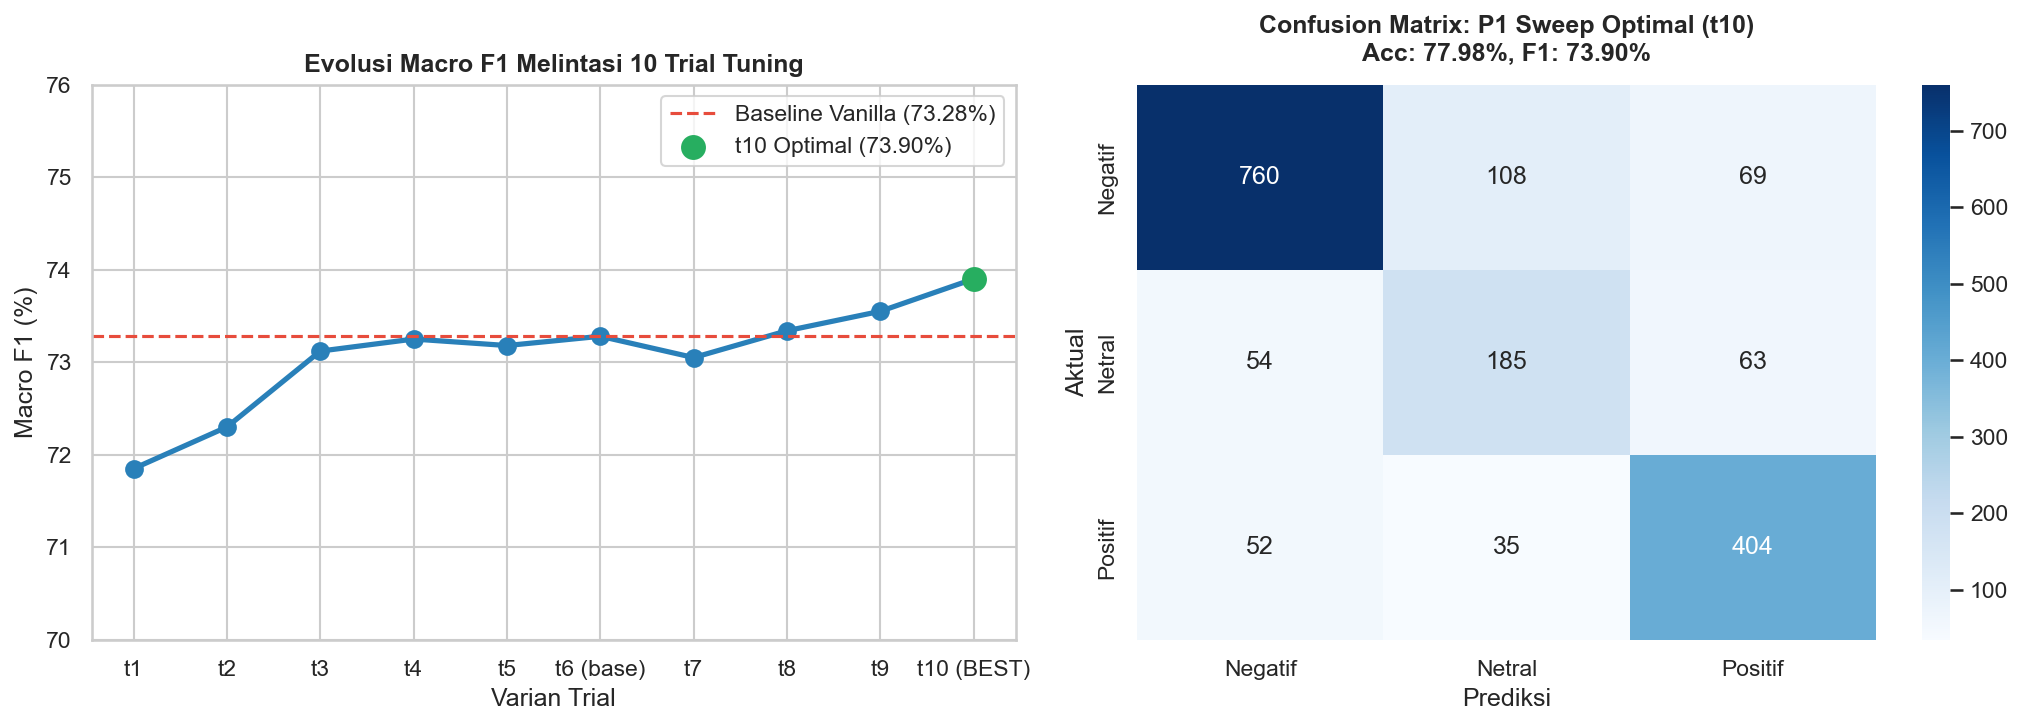

In [4]:
target_names = ['Negatif', 'Netral', 'Positif']
cm = confusion_matrix(y_te, preds)
pd.DataFrame(cm, index=[f"Aktual_{c}" for c in target_names], columns=[f"Pred_{c}" for c in target_names]).to_csv(CM_DIR / f"cm_{MODEL_NAME}.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar plot Macro F1 across trials
axes[0].plot(df_sweep['trial'], df_sweep['test_f1'], marker='o', color='#2980b9', lw=2.5, markersize=8)
axes[0].axhline(y=73.28, color='#e74c3c', linestyle='--', label='Baseline Vanilla (73.28%)')
axes[0].scatter(9, 73.90, color='#27ae60', s=120, zorder=5, label='t10 Optimal (73.90%)')
axes[0].set_title("Evolusi Macro F1 Melintasi 10 Trial Tuning", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Varian Trial")
axes[0].set_ylabel("Macro F1 (%)")
axes[0].set_ylim(70, 76)
axes[0].legend()

# 2. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_title(f"Confusion Matrix: P1 Sweep Optimal (t10)\nAcc: {acc*100:.2f}%, F1: {f1*100:.2f}%", fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("Aktual")

plt.tight_layout()
plt.savefig(CM_DIR / f"cm_{MODEL_NAME}.png", dpi=300, bbox_inches='tight')
plt.show()


### 5. Kesimpulan Akademis
1. **Bukti Batas Hyperparameter (*Performance Ceiling*)**:
   Variasi 10 trial membuktikan bahwa tuning parameter konvensional (LR, epoch, warmup, weight decay) hanya mampu menaikkan Macro F1 secara marjinal dari **73,28% menjadi 73,90%** (+0,62 pp).
2. **Kebutuhan Adaptasi Representasi Bahasa (P2 TAPT)**:
   Karena batas maksimal hyperparameter telah tercapai, langkah berikutnya untuk menembus Macro F1 $\ge 0,80$ adalah melakukan adaptasi domain kosakata lokal melalui **Task-Adaptive Pretraining (TAPT)** pada korpus banjir.
